In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import torch
from transformers import BlipForConditionalGeneration


In [ ]:
model_names = [
    "divag/blip-ucm-captioning_after_f1",
    "OmPatil3690/blip-rsicd_1-captioning-after-f1"
]


In [ ]:
local_paths = []

for name in model_names:
    local_dir = f"./{name.split('/')[-1]}"  # folder name

    print(f"⬇️ Downloading {name}...")

    model = BlipForConditionalGeneration.from_pretrained(name)

    model.save_pretrained(local_dir)  #save locally

    local_paths.append(local_dir)

    print(f"✅ Saved at {local_dir}")

⬇️ Downloading divag/blip-ucm-captioning_after_f1...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved at ./blip-rsicd_1-captioning-after-f1


In [ ]:
models = [
    BlipForConditionalGeneration.from_pretrained(p)
    for p in local_paths
]

print(" Loaded all local models")

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


 Loaded all local models


In [ ]:
state_dicts = [m.state_dict() for m in models]


In [ ]:
avg_state_dict = {}

for key in state_dicts[0].keys():
    try:
        weights = torch.stack([sd[key].float() for sd in state_dicts])
        avg_state_dict[key] = weights.mean(dim=0)
    except:
        avg_state_dict[key] = state_dicts[0][key]

print(" Averaging complete")


 Averaging complete


In [ ]:
global_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

global_model.load_state_dict(avg_state_dict, strict=False)

print("Global model ready")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Global model ready


In [ ]:
SAVE_PATH = "./blip-federated_2"

global_model.save_pretrained(SAVE_PATH)

print(" Federated model saved at:", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Federated model saved at: ./blip-federated_2


In [ ]:
from huggingface_hub import login

login("TOKEN")

from huggingface_hub import create_repo, upload_folder

repo_name = "OmPatil3690/blip-federated_2"

create_repo(repo_name, exist_ok=True)

upload_folder(
    folder_path=SAVE_PATH,
    repo_id=repo_name,
    repo_type="model"
)

print("Uploaded via folder!")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rated_2/model.safetensors:   0%|          |  572kB /  990MB            

Uploaded via folder!


In [ ]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_ID = "OmPatil3690/blip-federated_2"

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(MODEL_ID).to(device)
model.eval()

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ompatil07","key":"d55cb55bfe9369a43409697114d0e9a9"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d thedevastator/rsicd-image-caption-dataset
!unzip *.zip

Dataset URL: https://www.kaggle.com/datasets/thedevastator/rsicd-image-caption-dataset
License(s): CC0-1.0
100% 677M/677M [00:13<00:00, 51.6MB/s]

Archive:  rsicd-image-caption-dataset.zip
  inflating: test.csv                
  inflating: train.csv               
  inflating: valid.csv               


In [ ]:
import pandas as pd
import json

df = pd.read_csv("/content/test.csv")

In [ ]:
from io import BytesIO
import matplotlib.pyplot as plt
import ast
from PIL import Image
import torch

def visualize_prediction(row):

    # 🔹 Decode image (FIXED)
    image_bytes = ast.literal_eval(row["image"])["bytes"]
    image = Image.open(BytesIO(image_bytes)).convert("RGB")

    # 🔹 Show image
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    # 🔹 Ground truth captions
    gt_captions = ast.literal_eval(row["captions"])

    print("🟢 Ground Truth Captions:")
    for i, cap in enumerate(gt_captions):
        print(f"{i+1}. {cap}")

    # 🔹 Generate caption
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_length=30,
            num_beams=5,
            no_repeat_ngram_size=2,
            early_stopping=True
        )

    pred_caption = processor.decode(output[0], skip_special_tokens=True)

    print("\n🔵 Generated Caption:")
    print(pred_caption)

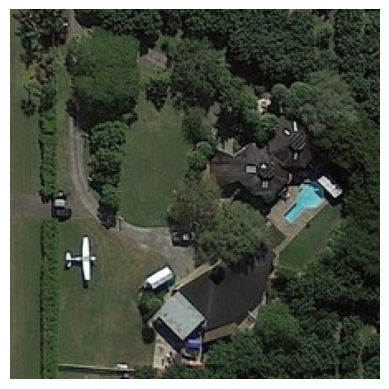

🟢 Ground Truth Captions:
1. there is a house and a swimming pool located in a lawn near the forest with a plane parked on the lawn.there is a house and a swimming pool located on a lawn near the forest with a plane parked on the lawn.there is a house and a swimming pool located in a lawn near the forest  with a aircraft parked on the lawn .an private airplane stands outside this smart house with a swimming pool inside it .a building with a swimming pool and a white plane is surrounded by many green plants .

🔵 Generated Caption:
a villa with grey roofs is surrounded by lawn in the sparse residential area.


In [ ]:
import random

idx = random.randint(0, len(df)-1)
visualize_prediction(df.iloc[idx])

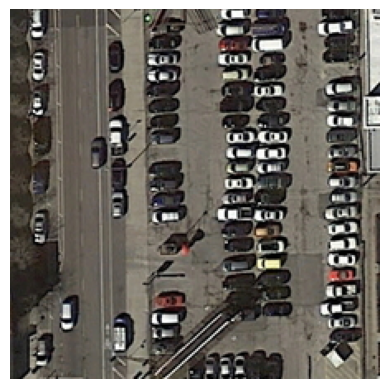

🟢 Ground Truth Captions:
1. Some cars are parked in parking spaces while others are parked along a street.some cars are parked in the square parking lots while some are parked along a street .there several cars parking next to the road .rows of cars crammed this rectangular parking lot .many cars are parked between a road and two buildings .

🔵 Generated Caption:
many cars parked in lines with a few free parking spots in the parking lot.


In [ ]:
idx = random.randint(0, len(df)-1)
visualize_prediction(df.iloc[idx])

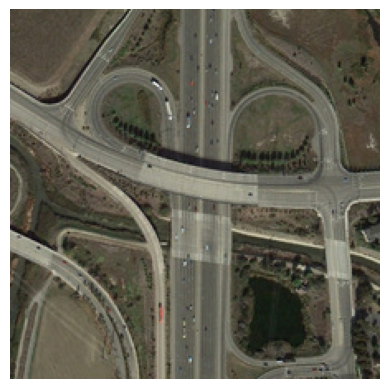

🟢 Ground Truth Captions:
1. two circular ramps of the viaduct form in shape like the eyes of an owl.there are two loops in the viaduct .two circular ramps of the viaduct forms into a shape like a owl's eyes .the slightly curved viaduct spans the bustling wide straight highway road on the ground .some scattered green trees and a pond are near a viaduct .

🔵 Generated Caption:
a road go across another two roads with some cars on the roads.


In [ ]:
idx = random.randint(0, len(df)-1)
visualize_prediction(df.iloc[idx])

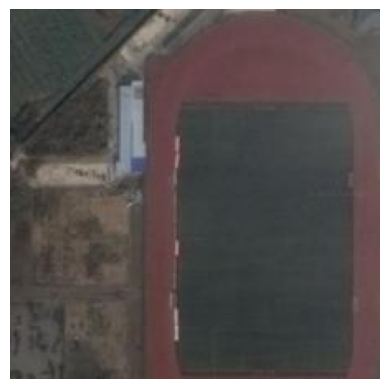

🟢 Ground Truth Captions:
1. the finished football field sits close to the street while other courts are under construction .a large playground is near a piece of farmland .a playground is surrounded by green plants.a large playground is next to a piece of green farmland .a playground is surrounded by green plants .

🔵 Generated Caption:
two tennis courts are surrounded by some plants and a road beside.


In [ ]:
idx = random.randint(0, len(df)-1)
visualize_prediction(df.iloc[idx])

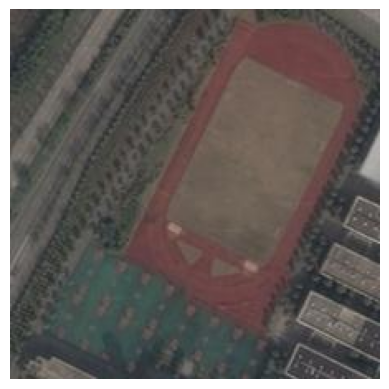

🟢 Ground Truth Captions:
1. there are many baksetball courts side by side while the turf of the football field has been yellowish .a playground and some basketball fields are surrounded by roads and some buildings .a playground next to a road is semi-rounded by many buildings.a playground with two rows of basketball fields are beside a row of buildings .a playground next to a road is semisurrounded by many buildings .

🔵 Generated Caption:
it is a small baseball diamond with sand and grass.


In [ ]:
idx = random.randint(0, len(df)-1)
visualize_prediction(df.iloc[idx])